# The drive

*Five sensorless observers ranked by what they measure, the firmware's own law searched over the 23-63 V link, speed and torque against the tolerances, and the rotor observer on the board's own PMSM model.*

**Abstract.** Device 10 holds the rotor at rest by injecting on the machine's saliency and hands over to back-EMF above `w_lo`; above that the angle is what an observer can make of `v - R i`, and this notebook asks which observer, at what speed, from what this board can measure. Five observers in `coaxial.model.sensorless` - sliding mode, flux linkage, extended state, adaptive Luenberger, dual flux with a PLL - run over plants drawn around the 5230SL with the Monte Carlo's own tolerances and are ranked by angle error in degrees rms against a 20-degree line, the error a torque command pays as `1 - cos`. The firmware's own C is then searched over the link sweep with `tools/sim/montecarlo.py`, one process per core, and its best tune verified with the injection off through the descent, which is the sensorless floor. The envelope both land in is read against the lambda tolerance, the thermal network and a low-saliency outrunner; last, the rotor observer runs on the stand-in's own PMSM model, the one source whose true angle is known, beside the back-EMF chain the board carries as a second answer. Headline numbers: dual flux with a PLL holds 0.7 degrees at 14 rpm where the plain flux observer holds 53; the chain of the two holds under 7 degrees from 14 to 10 231 rpm at 63 V, better than 99 % of the commanded torque; the back-EMF alone loses the rotor at 10 to 31 rpm; peak torque is 3.92 to 4.79 N.m at the board's 100 A and continuous torque a quarter of it, thermal; the board steps the law in 2 921 of a period's 4 750 ticks. What a reader takes to the bench: the floor is the injection's and the ceiling the link's, the weight between observers should come from what each says about itself, and the one measurement that moves most of the envelope is the phase node's spreading resistance with current flowing.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 The plant, drawn around the 5230SL

`tools/sim/montecarlo.py` runs the firmware's own C - the current loop, the injection demodulator, the rotor observer, the dead-time table - through `test_drive_core.py`'s bench against `drive_model.c`, one process per core. A plant is drawn around the 5230SL that the controller was not told about: copper to 125 C on R, a quarter either way on L, saliency from barely there to 1.5, the dead time either side of the commissioned one, the AFE at its measured floor, the rotor inside the injection's pull-in. The cost of a run is `sigma_theta + speed_err + 10 trip`, a robustness figure because the plant is never the fitted one. Every simulation below draws its plants with `mc.draw`, so the observers and the search are judged over one spread.

In [3]:
import os
import sys

sys.path.insert(0, os.path.join('..', 'host'))   # the Monte Carlo is a tool beside the library, not part of it
from tools.sim import montecarlo as mc

In [4]:
print('link sweep', mc.VDC_SWEEP)
print('knobs', {k: v[:2] for k, v in mc.KNOBS.items()})
print('I_MAX %.0f  I_TRIP %.0f  I_H_MAX %.0f  TOP %.2f  LOST %.2f rad'
      % (mc.I_MAX, mc.I_TRIP, mc.I_H_MAX, mc.TOP, mc.LOST))
plant = mc.draw(1, 43.0)
print({k: round(v, 6) for k, v in plant.items()})

link sweep (23.0, 33.0, 43.0, 53.0, 63.0)
knobs {'bw_i': (300.0, 2500.0), 'f_pll': (20.0, 400.0), 'zeta': (0.5, 1.2), 'v_inj': (0.02, 0.2), 'n_inj': (1, 4), 'w_lo': (50.0, 800.0), 'w_ratio': (1.5, 4.0), 'bw_w': (1.0, 20.0)}
I_MAX 60  I_TRIP 100  I_H_MAX 5  TOP 0.50  LOST 0.35 rad
{'r': 0.039602, 'ld': 1.8e-05, 'lq': 2.1e-05, 'lambda': 0.002071, 'pole_pairs': 14.0, 'sat': 0.3, 'i_sat': 40.0, 'j': 0.000141, 'b': 0.000253, 'load': 0.0, 'v_dt': 0.082524, 'i_knee': 11.289512, 'vdc': 43.0, 'noise': 0.355632, 'theta0': 0.178112, 'sub': 4.0, 'theta_err0': 0.805836, 'k_prop': 5e-06}


## 3 Sliding mode against flux linkage over the speed sweep

The two oldest back-EMF observers, side by side over seven held speeds and five drawn plants, fed nothing but the phase voltages and currents at 2 A of torque current. The sliding-mode observer runs the stator's current equation as a model with a switching term driving its current onto the measured one; once it slides that term is the back-EMF, low-passed, and `e = lambda w (-sin, cos)` gives the angle. The flux observer integrates `v - R i`, and `psi - L i` is the rotor's flux, whose angle is the rotor's. Each carries a residual that needs no truth: the sliding-mode current error in units of the AFE's floor, and the flux magnitude against lambda. A torque command at an angle error `eps` delivers `cos(eps)` of itself - 20 degrees electrical costs 6 %, 40 costs 23 % - so 20 degrees is the line each has to stay inside.

In [5]:
import math
from coaxial.model import inverter, sensorless
from coaxial.control.loop import CurrentLoop, Machine, Signals
from coaxial.model.motor import PLATINUM_5230SL, Parameters

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
SPEEDS = (20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0)
PLANTS = 5
CRITERION_DEG = 20.0
#: Where the blend hands over from sliding mode to flux linkage, rad/s
#: electrical - a band about the crossover, not a threshold.
BLEND_BAND = (400.0, 1400.0)

def rpm(w_e):
    return w_e / motor.poles * 60.0 / TWO_PI

def fitted_of(plant, r_error=0.0):
    """The drawn plant as the parameters an observer is handed."""
    return Parameters(name='drawn', r=plant['r'] * (1.0 + r_error),
                      ld=plant['ld'], lq=plant['lq'], lam=plant['lambda'],
                      poles=int(plant['pole_pairs']), measured=False)

def stationary(s):
    """The dq solution and the currents rotated out to alpha-beta: what
    the board's chain gets too, there being no phase-voltage sense."""
    c, sn = math.cos(s.theta), math.sin(s.theta)
    return (s.vd * c - s.vq * sn, s.vd * sn + s.vq * c,
            s.id * c - s.iq * sn, s.id * sn + s.iq * c)

def deg_rms(errors):
    return math.degrees(math.sqrt(sum(e * e for e in errors) / len(errors)))

def observe(plant, w_e, seconds=0.4):
    """Both observers against a rotor held at w_e: degrees rms, the
    blend of the two, and each one's own residual."""
    fitted = fitted_of(plant)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    smo = sensorless.SlidingModeObserver(
        fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0)
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    got = {'smo': [], 'flux': [], 'gap': [], 'blend': []}
    res = {'smo': [], 'flux': []}
    lo, hi = BLEND_BAND
    share = 0.0
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        va, vb, ia, ib = stationary(s)
        th_s = smo.update(va, vb, ia, ib, dt)
        th_f = flux.update(va, vb, ia, ib, dt)
        if s.t <= 0.5 * seconds:
            continue
        got['smo'].append(mc.wrap(th_s - s.theta))
        got['flux'].append(mc.wrap(th_f - s.theta))
        got['gap'].append(mc.wrap(th_s - th_f))
        res['smo'].append(math.hypot(smo.i_alpha - ia, smo.i_beta - ib)
                          / max(plant['noise'], 1e-3))
        psi = math.hypot(flux.psi_alpha - fitted.ld * ia,
                         flux.psi_beta - fitted.ld * ib)
        res['flux'].append(abs(psi - fitted.lam) / fitted.lam)
        # The blend, ramped over BLEND_BAND on the observer's own speed and
        # applied to the unit vectors - an angle is not a quantity you average.
        f = min(1.0, max(0.0, (abs(smo.omega) - lo) / (hi - lo)))
        x = (1.0 - f) * math.cos(th_s) + f * math.cos(th_f)
        y = (1.0 - f) * math.sin(th_s) + f * math.sin(th_f)
        got['blend'].append(mc.wrap(math.atan2(y, x) - s.theta))
        share += 1.0 - f
    out = {k: deg_rms(v) for k, v in got.items()}
    out['share'] = share / len(got['blend'])
    out['res_smo'] = sum(res['smo']) / len(res['smo'])
    out['res_flux'] = sum(res['flux']) / len(res['flux'])
    return out

def median(values):
    return values[len(values) // 2]

plants = [mc.draw(90 + i, 43.0) for i in range(PLANTS)]
table = []
print('deg rms over %d drawn plants, iq 2 A; the residuals are the median plant' % PLANTS)
print('  rad/s el    rpm   SMO deg rms   resid    flux deg rms   wc/w   |psi|   apart')
print('                   median  worst  sigma_i  median  worst    deg   off %     deg')
for w_e in SPEEDS:
    rows = [observe(p, w_e) for p in plants]
    row = {k: sorted(r[k] for r in rows) for k in rows[0]}
    row['w_e'] = w_e
    table.append(row)
    print('%10.0f %6.0f %9.1f %6.1f %8.2f %9.1f %6.1f %7.1f %7.1f %7.1f'
          % (w_e, rpm(w_e), median(row['smo']), row['smo'][-1],
             median(row['res_smo']), median(row['flux']), row['flux'][-1],
             math.degrees(math.atan2(20.0, w_e)), 100.0 * median(row['res_flux']),
             median(row['gap'])))

def band_of(which):
    """(lowest, highest) swept speed whose worst plant is inside the
    criterion; nan and nan when none is."""
    inside = [row['w_e'] for row in table if row[which][-1] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (math.nan, math.nan)

print()
for which, name in (('smo', 'sliding mode'), ('flux', 'flux linkage'),
                    ('blend', 'the two blended')):
    lo, hi = band_of(which)
    print('%-15s inside %.0f deg from %5.0f to %5.0f rad/s = %4.0f to %5.0f rpm'
          % (name, CRITERION_DEG, lo, hi, rpm(lo), rpm(hi)))

deg rms over 5 drawn plants, iq 2 A; the residuals are the median plant
  rad/s el    rpm   SMO deg rms   resid    flux deg rms   wc/w   |psi|   apart
                   median  worst  sigma_i  median  worst    deg   off %     deg


        20     14      18.5   19.6     3.64      52.9   53.0    45.0    30.7    55.1


        50     34       7.4    7.8     3.93      36.0   36.1    21.8     7.8    36.4


       100     68       4.3    4.8     4.57      23.3   23.3    11.3     2.1    23.4


       200    136       2.7    3.0     5.86      12.0   12.0     5.7     0.8    11.9


       500    341       2.2    2.2    10.47       5.4    5.4     2.3     0.7     5.7


      1000    682       3.0    3.1    17.78       3.5    3.5     1.1     0.6     4.9


      2000   1364       5.5    5.7    33.82       3.2    3.3     0.6     0.6     7.4

sliding mode    inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm
flux linkage    inside 20 deg from   200 to  2000 rad/s =  136 to  1364 rpm
the two blended inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm


The sliding-mode observer degrades at both ends for different reasons: low down the back-EMF is small against `R i` and the boundary layer, so the error grows as the signal shrinks; high up the lag `atan(w/wc)` is a large correction - 76 degrees at 2000 rad/s with `wc` 500 - resting on the speed estimate under it. `k` is sized from `lambda w` rather than tuned, and the switching term absorbs what R and L get wrong, which is the point of it. The flux observer's integrator leaks at `wc` to hold off the drift a pure one walks away on, and the leak costs exactly what it saves: `sqrt(1 + (wc/w)^2)` short and `atan(wc/w)` late, 45 degrees at `w = wc` and nothing below it. Above the corner it is the quieter of the two by a growing margin, and lambda falls out of it.

## 4 The second inductance

`psi - L i` needs one L, and a salient machine has two. Subtracting Ld along both axes leaves `(Lq - Ld) iq` on the q axis of what is supposed to be the rotor's flux, so the estimate is pulled round by an angle that grows with load and vanishes at no load - a flux observer looks perfect on a bench and loses the rotor pulling a propeller. The extended back-EMF form is the same physics arranged so it cannot: with Ld in both axes everything left over goes into `E_ex = (Ld - Lq)(w id - d iq/dt) + w lambda`, which points along the plain back-EMF, so an observer estimating it recovers the angle with no saliency error. At the 2 A the sweep runs the error is a fifth of a degree, which is how it gets missed; at the rated current it is a bias that moves with torque, not noise that averages out. `sensorless.FluxObserver` is the plain form: on a surface-magnet outrunner the two coincide, and the more saliency a machine has, the more the injection has at rest and the more the flux observer needs the extended form at speed - one constant paying twice in opposite directions.

In [6]:
print('what one L costs the plain flux observer under load, 5230SL')
print('Ld %.1f uH, Lq %.1f uH, saliency %.2f, lambda %.5f Wb'
      % (motor.ld * 1e6, motor.lq * 1e6, motor.saliency, motor.lam))
print()
print('   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %')
for iq in (0.0, 2.0, 10.0, 30.0, 60.0, 100.0):
    stray = (motor.lq - motor.ld) * iq
    err = math.atan2(stray, motor.lam)
    print('%7.0f %17.1f %17.2f %13.1f'
          % (iq, stray * 1e6, math.degrees(err), 100.0 * (1.0 - math.cos(err))))
print()
print('the extended back-EMF form carries the term instead: zero at every iq')

what one L costs the plain flux observer under load, 5230SL
Ld 22.0 uH, Lq 29.0 uH, saliency 1.32, lambda 0.00207 Wb

   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %
      0               0.0              0.00           0.0
      2              14.0              0.39           0.0
     10              70.0              1.93           0.1
     30             210.0              5.79           0.5
     60             420.0             11.46           2.0
    100             700.0             18.66           5.3

the extended back-EMF form carries the term instead: zero at every iq


## 5 Five observers, ranked by measurement

Three more, all in `coaxial.model.sensorless`. The extended state observer (ESO, ADRC) refuses to model anything: `di/dt = v/L + f` and `f` is everything else at once, estimated as a state, so there is no low-pass on the signal it wants and nothing in its angle rests on the speed it is estimating; one knob, `wo`, with both poles there, and at the drive's 20 us explicit step `wo` past about 12 000 rad/s is where the second pole stops being stable - six times the top of this sweep. The adaptive Luenberger observer integrates the current error into a back-EMF and adapts R from the part of that error along the current, because a winding rises 0.4 % per kelvin and the R it was handed at commissioning is not the R an hour of load leaves. The dual flux observer has two flux models correcting each other - the voltage model right at speed, the current model `L i + lambda` right at rest - so there is no leak and no `atan(wc/w)` to pay, and the angle comes off a PLL so the speed falls out of the loop rather than a subtraction. Same plants, same step, same current; the speed states start where a running drive would leave them.

In [7]:
RANKED = ('dual', 'smo', 'luen', 'eso', 'flux')

def five(fitted, w_e):
    """One of each, with the states a running drive would hand over."""
    made = {
        'eso': sensorless.ExtendedStateObserver(fitted.r, fitted.ld, wo=12000.0),
        'luen': sensorless.AdaptiveLuenberger(fitted.r, fitted.ld),
        'dual': sensorless.DualFluxObserver(fitted.r, fitted.ld, fitted.lam,
                                            cross=20.0),
        'smo': sensorless.SlidingModeObserver(
            fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0),
        'flux': sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0),
    }
    for one in made.values():
        one.omega = w_e
    return made

def compare(plant, w_e, seconds=1.0, iq=2.0):
    """All five against a rotor held at w_e. Degrees rms."""
    fitted = fitted_of(plant)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    made = five(fitted, w_e)
    s = Signals()
    s.iq_ref = iq
    err = {k: [] for k in made}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        va, vb, ia, ib = stationary(s)
        for name, one in made.items():
            th = one.update(va, vb, ia, ib, dt)
            if s.t > 0.5 * seconds:
                err[name].append(mc.wrap(th - s.theta))
    return {k: deg_rms(v) for k, v in err.items()}

ranked = []
print('deg rms, median of %d plants, iq 2 A' % PLANTS)
print('  rad/s el    rpm ' + ''.join('%8s' % n for n in RANKED))
for w_e in (20.0, 100.0, 500.0, 2000.0):
    rows = [compare(p, w_e) for p in plants]
    got = {name: median(sorted(r[name] for r in rows)) for name in RANKED}
    ranked.append((w_e, got))
    print('%10.0f %6.0f ' % (w_e, rpm(w_e)) + ''.join('%8.1f' % got[n] for n in RANKED))
print()
for name in RANKED:
    print('%-6s %5.1f deg at its best, %5.1f at its worst'
          % (name, min(row[1][name] for row in ranked), max(row[1][name] for row in ranked)))

deg rms, median of 5 plants, iq 2 A
  rad/s el    rpm     dual     smo    luen     eso    flux


        20     14      0.7     8.9    84.0    61.2    52.6


       100     68      0.7     2.0    26.5    11.0    23.1


       500    341      1.1     1.0     4.7     4.9     5.2


      2000   1364      3.5     2.5     1.8    17.0     2.4

dual     0.7 deg at its best,   3.5 at its worst
smo      1.0 deg at its best,   8.9 at its worst
luen     1.8 deg at its best,  84.0 at its worst
eso      4.9 deg at its best,  61.2 at its worst
flux     2.4 deg at its best,  52.6 at its worst


The ranking is not the one the literature's reputations suggest, and it matters which parts are the method and which are this bench. Dual flux with a PLL wins, by an order of magnitude where the others are weakest: the only one of the five with neither a lag to correct nor a leak to pay for, and the PLL keeps its speed out of a difference - a property of the arrangement, not of this simulation. The sliding-mode observer is the solid one across the range and the cheapest to reason about, which is why it is the classic. The adaptive Luenberger is best at the top and useless at the bottom, a back-EMF observer behaving like one; its adaptation does not converge in this arrangement - `e_hat` and `r_hat` feed on one residual and `e_hat` is three orders faster - which says R needs an excitation the back-EMF cannot explain, the d-axis current `commission.deadtime` already applies offline. The ESO comes last, and that is this bench: its case is sound, but the bandwidth has to fit inside a 20 us forward-Euler step, and 12 000 rad/s is what this step can carry.

## 6 The hybrid

The two oldest fail at opposite ends, so there are three ways to use the pair, in rising order of what they ask for. Switch on speed with hysteresis: no extra state, but a threshold where both are marginal is one the estimate chatters across, and the commutation rests on the estimate. Blend over a band on the observer's own speed, the shape the firmware uses between injection and back-EMF over `w_lo .. w_hi`: the two disagree by a few degrees in the overlap, and a step of that size in the commutation angle is a step in torque, so a ramped weight on the unit vectors removes it for a multiply. Weight on each observer's own residual: neither needs truth to say how it is doing. The table is the blend from section 3 read back, with what it gained over the better single observer at each speed, and the cost of each against the drive step's own 2 921 cycles.

In [8]:
print('the blend, %.0f to %.0f rad/s = %.0f to %.0f rpm'
      % (BLEND_BAND[0], BLEND_BAND[1], rpm(BLEND_BAND[0]), rpm(BLEND_BAND[1])))
print('  rad/s el    rpm   SMO share   blend deg rms   best single   gained')
for row in table:
    single = min(median(row['smo']), median(row['flux']))
    got = median(row['blend'])
    print('%10.0f %6.0f %10.2f %14.1f %13.1f %8.1f %%'
          % (row['w_e'], rpm(row['w_e']), median(row['share']), got, single,
             100.0 * (single - got) / single))
print()
print("cost, per step, against the drive step's own %d cycles:" % 2921)
print('   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2')
print('   flux linkage   2 integrators, one atan2, a sqrt and an atan')
print('   the blend      one ramp, two multiplies, one atan2')
print('   headroom       %d cycles a period at %.0f kHz'
      % (2 * 2375 - 2921, 1e-3 / inverter.TS))

the blend, 400 to 1400 rad/s = 273 to 955 rpm
  rad/s el    rpm   SMO share   blend deg rms   best single   gained
        20     14       1.00           18.5          18.5      0.0 %
        50     34       1.00            7.4           7.4      0.0 %
       100     68       1.00            4.3           4.3      0.0 %
       200    136       1.00            2.7           2.7      0.0 %
       500    341       0.90            2.1           2.2      4.2 %
      1000    682       0.40            2.2           3.0     25.1 %
      2000   1364       0.00            3.2           3.2      0.0 %

cost, per step, against the drive step's own 2921 cycles:
   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2
   flux linkage   2 integrators, one atan2, a sqrt and an atan
   the blend      one ramp, two multiplies, one atan2
   headroom       1829 cycles a period at 50 kHz


## 7 What the flux magnitude says about the magnets

The angle is not all that is in the residuals. The flux observer's rotor flux has a magnitude as well as a direction, and that magnitude is lambda - the one constant that says what the magnets are doing, and nothing else on this board can see them: the NTC is on the PCB and the rotor is across an air gap. So the observer that commutates the machine is also measuring it, for one `hypot` a step. What corrupts the measurement is R: the flux integrates `v - R i`, so an error in R lands in the flux, and hardest where `R i` is a large share of `v`, at low speed. The table runs one plant over the sweep with R exact and 30 % off either way, and reads the magnitude as a fraction of the true lambda.

In [9]:
def identify_lambda(plant, w_e, r_error=0.0, seconds=0.4):
    """What the flux observer's magnitude says lambda is, with R off by
    `r_error` as a fraction: the estimate over the truth."""
    fitted, truth = fitted_of(plant, r_error), fitted_of(plant)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(truth, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    seen = []
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        va, vb, ia, ib = stationary(s)
        flux.update(va, vb, ia, ib, dt)
        if s.t > 0.5 * seconds:
            seen.append(math.hypot(flux.psi_alpha - fitted.ld * ia,
                                   flux.psi_beta - fitted.ld * ib))
    return (sum(seen) / len(seen)) / truth.lam

recovered = {}
print('lambda recovered from |psi_r|, as a fraction of the truth')
print('  rad/s el    rpm    R exact   R +30 %   R -30 %')
for w_e in SPEEDS:
    recovered[w_e] = [identify_lambda(plants[0], w_e, e) for e in (0.0, 0.3, -0.3)]
    print('%10.0f %6.0f %10.3f %9.3f %9.3f' % ((w_e, rpm(w_e)) + tuple(recovered[w_e])))

lambda recovered from |psi_r|, as a fraction of the truth
  rad/s el    rpm    R exact   R +30 %   R -30 %


        20     14      0.695     0.317     1.072

        50     34      0.923     0.725     1.121


       100     68      0.979     0.874     1.084


       200    136      0.994     0.941     1.048


       500    341      0.999     0.978     1.020
      1000    682      1.000     0.989     1.010


      2000   1364      1.000     0.994     1.005


## 8 The firmware's law over the link sweep

A run is a lock from a random error, a raised cosine to half the link's no-load speed, a hold, a descent under injection again; the statistics start after the lock. Two rounds per link voltage: a Latin hypercube over the knobs, then a half-box about the best three, and the best per link is verified against fresh draws with and without the injection through the descent - `min_rpm` is where the back-EMF alone lost the rotor, the sensorless floor. A small search here so the notebook executes in seconds; the tool's defaults are 48 candidates, 16 draws and 24 refinements per link. The tool's progress lines are held back; what it found is printed, and the figure is every run's cost against the link beside the best tune's mean and 90th percentile.

In [10]:
import contextlib
import io
import time

VDCS = (23.0, 43.0, 63.0)
t0 = time.perf_counter()
with mc.pool() as p, contextlib.redirect_stdout(io.StringIO()):
    best, runs = mc.search(p, vdcs=VDCS, candidates_n=6, draws=2, refine=3)
    checked = mc.verify(p, best, draws=4)
print('%d runs in the search, %d in the verification, %.0f s on %d cores'
      % (len(runs), len(checked), time.perf_counter() - t0, os.cpu_count()))
print('draws per point  %d plants, each drawn around the 5230SL' % 2)
print('cost             sigma_theta + speed_err + 10 x trip')
verified = checked[~checked.bemf_only]
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    print('%4.0f V  robust %.3f  bw_i %6.0f Hz  f_pll %5.0f Hz  zeta %.2f  v_inj %.3f  n_inj %d'
          % (vdc, row.robust, row.bw_i, row.f_pll, row.zeta, row.v_inj, int(row.n_inj)))
    print('        verified sigma_theta %.4f rad (%.2f deg), trips %d of %d'
          % (sub.sigma_theta.mean(), math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub)))
floor = checked[checked.bemf_only].groupby('vdc')['min_rpm'].agg(['mean', 'max', 'count'])
print()
print('the sensorless floor: rpm where the back-EMF alone lost the rotor')
print(floor.round(0))
print('trips with injection: %d of %d' % (int(verified.trip.sum()), len(verified)))

54 runs in the search, 24 in the verification, 5 s on 16 cores
draws per point  2 plants, each drawn around the 5230SL
cost             sigma_theta + speed_err + 10 x trip
  23 V  robust 0.084  bw_i   1187 Hz  f_pll    83 Hz  zeta 0.53  v_inj 0.200  n_inj 1
        verified sigma_theta 0.0388 rad (2.22 deg), trips 0 of 4
  43 V  robust 0.095  bw_i    948 Hz  f_pll    50 Hz  zeta 0.50  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0475 rad (2.72 deg), trips 0 of 4
  63 V  robust 0.121  bw_i    948 Hz  f_pll    50 Hz  zeta 0.50  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0766 rad (4.39 deg), trips 0 of 4

the sensorless floor: rpm where the back-EMF alone lost the rotor
      mean   max  count
vdc                    
23.0  31.0  35.0      4
43.0  10.0  22.0      4
63.0  14.0  30.0      4
trips with injection: 0 of 12


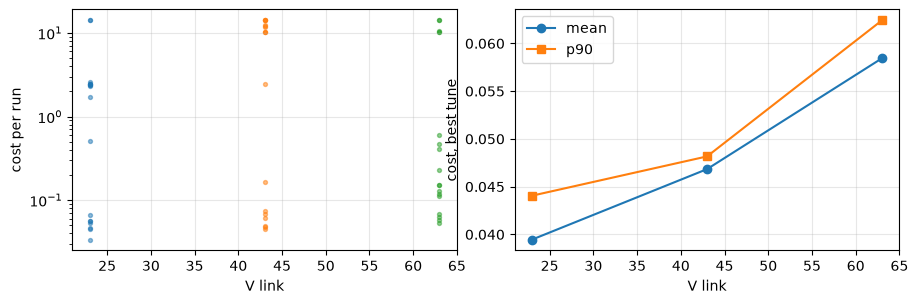

In [11]:
from coaxial.draw.figures import figure, show

fig, (a, b) = figure(rows=1, cols=2)
for vdc in VDCS:
    sub = runs[runs.vdc == vdc]
    a.scatter([vdc] * len(sub), sub.cost, s=8, alpha=0.5)
a.set_xlabel('V link')
a.set_ylabel('cost per run')
a.set_yscale('log')
b.plot(best.vdc, best['mean'], 'o-', label='mean')
b.plot(best.vdc, best.p90, 's-', label='p90')
b.set_xlabel('V link')
b.set_ylabel('cost, best tune')
b.legend()
show(fig)

Expected performance follows from the search and the machine. The no-load speed is what the modulator can hold against the back-EMF, `V_FRAC Vdc/sqrt(3) / lambda`, with `V_FRAC` 0.95 of the link the vector may use. With an APC20x10E on the shaft the held speed is where the propeller's `k w^2` meets the torque the current ceiling makes, or that no-load speed, whichever comes first - the last column names which. Torque and top speed do not coexist: the shaft power is at the operating point, not the product of the two ceilings. Under it, what the search chose per link and what it implies: the current loop against the ceiling two periods of pipeline delay allow, the injection frequency and depth, the blend band in rpm, the held angle error in electrical and mechanical degrees, and the floor as a share of the speed that link holds.

In [12]:
from coaxial.model.motor import APC20x10E, RATINGS, KT_NM_PER_AMP

kt = 1.5 * motor.poles * motor.lam
print('Kt               %.4f N.m/A  (the sheet: %.4f)' % (kt, KT_NM_PER_AMP))
print('board rating     %.0f A instantaneous, %.0f V link' % (100.0, 63.0))
print('motor rating     %.1f A burst for %.0f s, %.0f W'
      % (RATINGS['i_max'], RATINGS['t_i_max'], RATINGS['p_max']))
print('the limit        %s' % ('the inverter' if 100.0 < RATINGS['i_max'] else 'the motor'))
print()
print('with an APC20x10E on the shaft, the operating point:')
print('link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by')
operating = {}
for vdc in (23.0, 33.0, 43.0, 53.0, 63.0):
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    no_load = w_e / motor.poles
    by_current = math.sqrt(kt * 100.0 / APC20x10E.k)
    wm = min(by_current, no_load)
    torque = APC20x10E.k * wm * wm
    operating[vdc] = (no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque)
    print('%4.0f V %10.0f %11.0f %7.2f %10.2f %7.1f %12.1f   %s'
          % (vdc, no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque,
             torque * wm / 1000.0, torque / kt, torque / kt / math.sqrt(2.0),
             'the link' if wm < by_current else 'the 100 A rating'))
print()
print('what the search chose, and what it implies:')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    top_rpm = rpm(inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam)
    print('%4.0f V' % vdc)
    print('   current loop   %.0f Hz of the %.0f Hz two periods of delay allow'
          % (row.bw_i, 50e3 * 0.05))
    print('   observer       %.0f Hz, zeta %.2f' % (row.f_pll, row.zeta))
    print('   injection      %.0f Hz at %.1f %% of Vdc/sqrt3, %d period(s)'
          % (50e3 / (2.0 * int(row.n_inj)), 100.0 * row.v_inj, int(row.n_inj)))
    print('   blend          %.0f to %.0f rad/s electrical = %.0f to %.0f rpm'
          % (row.w_lo, row.w_lo * row.w_ratio, rpm(row.w_lo), rpm(row.w_lo * row.w_ratio)))
    print('   held           sigma_theta %.2f deg electrical, %.3f deg mechanical'
          % (math.degrees(sub.sigma_theta.mean()),
             math.degrees(sub.sigma_theta.mean()) / motor.poles))
    print('   back-EMF alone loses the rotor at %.0f rpm = %.1f %% of the %.0f rpm this link holds'
          % (floor.loc[vdc, 'mean'], 100.0 * floor.loc[vdc, 'mean'] / top_rpm, top_rpm))

Kt               0.0435 N.m/A  (the sheet: 0.0435)
board rating     100 A instantaneous, 63 V link
motor rating     112.5 A burst for 42 s, 4985 W
the limit        the inverter

with an APC20x10E on the shaft, the operating point:
link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by
  23 V       4151        4151    0.97       0.42    22.3         15.8   the link
  33 V       5956        5956    2.00       1.25    46.0         32.5   the link
  43 V       7762        7762    3.40       2.76    78.1         55.2   the link
  53 V       9566        8785    4.35       4.00   100.0         70.7   the 100 A rating
  63 V      11371        8785    4.35       4.00   100.0         70.7   the 100 A rating

what the search chose, and what it implies:
  23 V
   current loop   1187 Hz of the 2500 Hz two periods of delay allow
   observer       83 Hz, zeta 0.53
   injection      25000 Hz at 20.0 % of Vdc/sqrt3, 1 period(s)
   blend          127 to 195 rad/s electrical = 

## 9 Speed and torque against the tolerances

Every number here moves with lambda, and the plants are drawn with lambda at plus or minus 10 %: speed goes as `1/lambda` and torque as `lambda`, so the two ends of the tolerance are the two ends of the envelope. The link sets the speed and the board's 100 A sets the torque; neither is the motor, whose 112.5 A burst sits above the rating. Continuous torque is the thermal network's and nothing else: the worst node's equilibrium against the record's throttle point, 90 % of the 125 C ceiling, housekeeping and drivers included, the same definition the thermal notebook uses. A burst from ambient runs at `P / capacity` and nothing else, the node holding 0.40 J/K and moving in seconds while the board under it moves in 6.8 minutes - which is why a burst is planned against `seconds_to_limit` and the envelope throttles at 90 % rather than waiting for the ceiling.

In [13]:
from coaxial.model import thermal

LAMBDA_SPREAD = (0.9, 1.1)          # what mc.draw draws over
I_RATING = 100.0                    # the board, instantaneous
R_PHASE = inverter.RDS_ON + inverter.SHUNT
CEILING_C = 125.0 * 0.90            # the record's throttle point
AMBIENT_C = thermal.AMBIENT
capacity = thermal.CFG['capacity']['phase_u']

def spread(f):
    """(min, max) of f over the lambda tolerance."""
    got = [f(motor.lam * s) for s in LAMBDA_SPREAD]
    return min(got), max(got)

def no_load_rpm(vdc, lam):
    return rpm(inverter.V_FRAC * vdc / math.sqrt(3.0) / lam)

print('link   no-load rpm            torque at 100 A       shaft kW at that torque')
print('         min    max            min     max            min     max')
for vdc in VDCS:
    speeds = spread(lambda lam: no_load_rpm(vdc, lam))
    torques = spread(lambda lam: 1.5 * motor.poles * lam * I_RATING)
    def shaft_kw(lam, vdc=vdc):
        # At the propeller's operating point, not at both ceilings at once.
        kt_l = 1.5 * motor.poles * lam
        wm = min(math.sqrt(kt_l * I_RATING / APC20x10E.k),
                 inverter.V_FRAC * vdc / math.sqrt(3.0) / lam / motor.poles)
        return APC20x10E.k * wm ** 3 / 1000.0
    powers = spread(shaft_kw)
    print('%4.0f V %7.0f %6.0f %14.2f %7.2f %14.2f %7.2f'
          % ((vdc,) + speeds + torques + powers))
print()
i_rms = thermal.continuous_amps(R_PHASE, CEILING_C)
iq_cont = i_rms * math.sqrt(2.0)
print('continuous, worst node at the %.1f C throttle point:' % CEILING_C)
print('   %.1f A rms a phase = %.1f A of iq = %.2f N.m' % (i_rms, iq_cont, kt * iq_cont))
print()
print('burst from ambient, the node on its own capacity (%.2f J/K):' % capacity)
print('   iq A   A rms   W a phase   K/s      s to the ceiling')
def burst_s(iq):
    return (CEILING_C - AMBIENT_C) / ((iq / math.sqrt(2.0)) ** 2 * R_PHASE / capacity)
for iq in (20.0, 40.0, 60.0, 100.0):
    p = (iq / math.sqrt(2.0)) ** 2 * R_PHASE
    print('%7.0f %7.1f %11.1f %7.1f %17.2f'
          % (iq, iq / math.sqrt(2.0), p, p / capacity, burst_s(iq)))

link   no-load rpm            torque at 100 A       shaft kW at that torque
         min    max            min     max            min     max
  23 V    3774   4613           3.92    4.79           0.32    0.58
  43 V    7056   8624           3.92    4.79           2.07    3.42
  63 V   10338  12635           3.92    4.79           3.42    4.62

continuous, worst node at the 112.5 C throttle point:
   19.6 A rms a phase = 27.7 A of iq = 1.21 N.m

burst from ambient, the node on its own capacity (0.40 J/K):
   iq A   A rms   W a phase   K/s      s to the ceiling
     20    14.1         1.1     2.6             33.02
     40    28.3         4.2    10.6              8.25
     60    42.4         9.5    23.8              3.67
    100    70.7        26.5    66.2              1.32


In [14]:
top = spread(lambda lam: no_load_rpm(63.0, lam))
low = spread(lambda lam: no_load_rpm(23.0, lam))
peak = spread(lambda lam: 1.5 * motor.poles * lam * I_RATING)
cont = spread(lambda lam: 1.5 * motor.poles * lam * iq_cont)
smo_rpm, flux_rpm = rpm(band_of('smo')[0]), rpm(band_of('flux')[0])
bemf_rpm = floor.loc[43.0, 'mean']
held = (math.degrees(verified.sigma_theta.min()), math.degrees(verified.sigma_theta.max()))

print('%-34s %.0f to %.0f rpm at 63 V' % ('MAXIMUM SPEED, no load', *top))
print('%-34s %.0f to %.0f rpm at 23 V' % ('', *low))
print('%-34s 0 rpm - it holds at rest' % 'MINIMUM SPEED, injection')
print('%-34s %.0f rpm, 43 V' % ('   back-EMF alone, firmware', bemf_rpm))
print('%-34s %.0f rpm' % ('   sliding mode, 20 deg', smo_rpm))
print('%-34s %.0f rpm' % ('   flux linkage, 20 deg', flux_rpm))
print('%-34s %.2f to %.2f N.m' % ('PEAK TORQUE, 100 A instantaneous', *peak))
print('%-34s %.2f to %.2f N.m (%.1f A of iq)' % ('CONTINUOUS TORQUE, thermal', *cont, iq_cont))
print('%-34s %.2f s at 100 A, %.2f s at 60 A'
      % ('BURST TO THE THROTTLE POINT', burst_s(100.0), burst_s(60.0)))
print('%-34s %.1f to %.1f deg electrical' % ('ANGLE ERROR, injection held', *held))

MAXIMUM SPEED, no load             10338 to 12635 rpm at 63 V
                                   3774 to 4613 rpm at 23 V
MINIMUM SPEED, injection           0 rpm - it holds at rest
   back-EMF alone, firmware        10 rpm, 43 V
   sliding mode, 20 deg            14 rpm
   flux linkage, 20 deg            136 rpm
PEAK TORQUE, 100 A instantaneous   3.92 to 4.79 N.m
CONTINUOUS TORQUE, thermal         1.09 to 1.33 N.m (27.7 A of iq)
BURST TO THE THROTTLE POINT        1.32 s at 100 A, 3.67 s at 60 A
ANGLE ERROR, injection held        1.8 to 6.6 deg electrical


## 10 A low-saliency machine

An outrunner is the case this has to survive. Saliency is what the injection lives on - the demodulator's gain goes as `Lq - Ld` - and an outrunner's magnets sit on the rotor surface, so there is little of it. The plants are drawn from 1.05 to 1.5, which spans the case where injection works and the case where it does not. `choose_injection` sizes the injection for each saliency at this AFE's measured floor and `decide` names the method at its 10 dB threshold, once with 5 A of HF current to spend and once with 1 A. Under the table, the control strategy for such a machine in the drive's own terms, and the thermal observer's numbers, which are the board's and travel with any motor bolted to it - except the continuous rating, which is conduction and moves with `r_phase` and with whatever the phase node's spreading resistance turns out to be once re-fitted with current flowing.

In [15]:
sigma_i = max(inverter.NOISE_A)
loop_hz = sensorless.current_loop(motor.r, motor.ld, 1.0 / inverter.TS, sigma_i, 43.0)['bw_hz']
print('             ---- 5 A of HF headroom ----   ---- 1 A ----')
print('saliency   SNR dB   method    i_h peak A   SNR dB   method')
methods = {}
for ratio in (1.02, 1.05, 1.15, 1.32, 1.5):
    wide, tight = (sensorless.choose_injection(
        motor.ld, motor.ld * ratio, sigma_i, 1.0 / inverter.TS, 50.0, 43.0,
        i_h_max=cap, bw_i_hz=loop_hz) for cap in (5.0, 1.0))
    if wide is None or tight is None:
        print('%8.2f   nothing fits' % ratio)
        continue
    methods[ratio] = (wide['i_h_peak'], sensorless.decide(wide['snr_db']),
                      sensorless.decide(tight['snr_db']))
    print('%8.2f %8.1f   %-9s %10.2f %8.1f   %-9s'
          % (ratio, wide['snr_db'], methods[ratio][1], wide['i_h_peak'],
             tight['snr_db'], methods[ratio][2]))
print()
print('the 5230SL sits at %.2f, sigma_i %.2f A rms' % (motor.saliency, sigma_i))
print()
hand_over, second = band_of('smo')[0], band_of('flux')[0]
print('CONTROL STRATEGY, low saliency')
print('   below the hand-over      I/f ramp on current, saturation pulse for polarity')
print('   hand-over at             %.0f rad/s = %.0f rpm, the sliding-mode floor'
      % (hand_over, rpm(hand_over)))
print('   w_lo .. w_hi             %.0f .. %.0f rad/s, blended not switched'
      % (hand_over, 2.0 * hand_over))
print('   second hand-over at      %.0f rad/s = %.0f rpm to flux linkage,'
      % (second, rpm(second)))
print('                            weighted on the two residuals, not on speed')
print('   current loop             %.0f Hz, a twentieth of %.0f kHz sampling'
      % (loop_hz, 1e-3 / inverter.TS))
print('   injection                clears 10 dB to saliency %.2f here; the cost is'
      % min(r for r, m in methods.items() if m[1] == 'injection'))
print('                            HF current, so i_h_max is the knob')
print()
print('THERMAL OBSERVER')
print('   node ceilings            125 C the FETs and the MCU, 105 C the board')
print('   throttle at              90 %% = %.1f C, and it acts by dropping MOE' % CEILING_C)
print('   continuous               %.1f A rms a phase = %.2f N.m' % (i_rms, kt * iq_cont))
print('   burst                    timed, not held: %.1f s at 100 A from ambient' % burst_s(100.0))
print('   sample the NTC every     30 s, against a board constant of %.1f min'
      % thermal.tau_minutes())
print('   re-fit first             the phase node to_board, with current flowing')

             ---- 5 A of HF headroom ----   ---- 1 A ----
saliency   SNR dB   method    i_h peak A   SNR dB   method
    1.02     10.7   injection       2.26      3.6   if_start 
    1.05     18.4   injection       2.26     11.3   injection
    1.15     20.0   injection       0.99     20.0   injection
    1.32     20.0   injection       0.53     20.0   injection
    1.50     20.0   injection       0.39     20.0   injection

the 5230SL sits at 1.32, sigma_i 0.41 A rms

CONTROL STRATEGY, low saliency
   below the hand-over      I/f ramp on current, saturation pulse for polarity
   hand-over at             20 rad/s = 14 rpm, the sliding-mode floor
   w_lo .. w_hi             20 .. 40 rad/s, blended not switched
   second hand-over at      200 rad/s = 136 rpm to flux linkage,
                            weighted on the two residuals, not on speed
   current loop             2500 Hz, a twentieth of 50 kHz sampling
   injection                clears 10 dB to saliency 1.02 here; the cost is
 

## 11 The observers against the machine this board drives

Everything here is read off this hardware or computed from what it reads. The board has three phase-current channels, a DC link channel, an NTC, two die thermometers and the supply senses; it has no phase-voltage sense, so the voltage every observer integrates is reconstructed from the commanded duties and the measured link - not a simplification for the simulation but what the electronics can do, and why the DC link channel sits in the loop rather than beside it. The sweep is the five observers and the chain the firmware runs - dual flux below 800 rad/s electrical, plain flux above 3000, blended between on the unit vectors - over the whole range the 63 V link can reach, on plants drawn at that link. Then each one's band inside the 20-degree line, and the machine in the quantities the board reads.

In [16]:
FULL = (20.0, 100.0, 500.0, 2000.0, 5000.0, 10000.0, 15000.0)
CHAIN_BAND = (800.0, 3000.0)
VDC_TOP = 63.0
ORDER = ('chain', 'dual', 'smo', 'flux', 'luen', 'eso')

def sweep_all(plant, w_e, seconds=0.6, iq=2.0):
    """Every observer and the chain, one held speed. Degrees rms."""
    fitted = fitted_of(plant)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    made = five(fitted, w_e)
    lo, hi = CHAIN_BAND
    s = Signals()
    s.iq_ref = iq
    err = {k: [] for k in ORDER}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        va, vb, ia, ib = stationary(s)
        angles = {n: o.update(va, vb, ia, ib, dt) for n, o in made.items()}
        g = min(1.0, max(0.0, (abs(made['dual'].omega) - lo) / (hi - lo)))
        x = (1.0 - g) * math.cos(angles['dual']) + g * math.cos(angles['flux'])
        y = (1.0 - g) * math.sin(angles['dual']) + g * math.sin(angles['flux'])
        angles['chain'] = math.atan2(y, x)
        if s.t > 0.5 * seconds:
            for n in ORDER:
                err[n].append(mc.wrap(angles[n] - s.theta))
    return {n: (math.nan if any(e != e for e in v) else deg_rms(v))
            for n, v in err.items()}

tall = [dict(mc.draw(90 + i, VDC_TOP), vdc=VDC_TOP) for i in range(PLANTS)]
grid = []
print('angle error deg rms, median of %d plants, %.0f V link' % (PLANTS, VDC_TOP))
print('  rad/s el     rpm ' + ''.join('%7s' % n for n in ORDER))
for w_e in FULL:
    rows = [sweep_all(p, w_e) for p in tall]
    got = {name: median(sorted(r[name] for r in rows)) for name in ORDER}
    grid.append((w_e, got))
    print('%10.0f %7.0f ' % (w_e, rpm(w_e)) + ''.join('%7.1f' % got[n] for n in ORDER))

angle error deg rms, median of 5 plants, 63 V link
  rad/s el     rpm   chain   dual    smo   flux   luen    eso


        20      14     0.5    0.5    8.9   52.5   84.1   61.4


       100      68     0.6    0.6    2.0   23.1   25.9   11.0


       500     341     1.1    1.1    1.0    5.2    4.7    4.9


      2000    1364     2.9    3.5    2.5    2.4    1.8   17.0


      5000    3410     3.0    8.2    6.2    3.0    4.9   41.0


     10000    6821     4.9   16.1   12.3    4.9   23.9   74.1


     15000   10231     7.0   24.0   18.8    7.0  162.0   98.0


In [17]:
TOP_RAD_S = inverter.V_FRAC * VDC_TOP / math.sqrt(3.0) / motor.lam

def band(name):
    inside = [w for w, got in grid if got[name] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (None, None)

print('WHAT THE BOARD MEASURES')
print('%-14s %-9s %13s   %s' % ('channel', 'unit', 'per count', 'floor'))
print('%-14s %-9s %13.5f   %s A rms measured'
      % ('Phase U/V/W', 'A', inverter.AFE_A_PER_COUNT, inverter.NOISE_A))
print('%-14s %-9s %13.6f   78.15 V full scale, 49.9k/2.2k' % ('DC bus', 'V', 78.15 / 65536))
print('%-14s %-9s %13s   30 mK, and it sits in the drivers hot spot' % ('NTC', 'centi-C', '-'))
print('%-14s %-9s %13s   0.125 K, reset by every AFE cycle' % ('A1335 TSEN', 'K/8', '-'))
print('%-14s %-9s %13s   the die itself, 810.5 ADC cycles' % ('MCU VSENSE', 'C', '-'))
print('   not measured: phase voltage (duty x DC link), rotor angle (only with a')
print('   magnet at the A1335), torque (Kt x iq, and Kt is the sheet, not a stand)')
print()
print('THE OBSERVERS AGAINST THE MACHINE THIS BOARD DRIVES')
print('%-7s %15s %10s %9s %13s' % ('', 'holds rpm', 'worst deg', 'torque', 'of the range'))
grip = {}
for name in ORDER:
    lo, hi = band(name)
    if lo is None:
        print('%-7s %15s' % (name, 'nowhere inside %.0f deg' % CRITERION_DEG))
        continue
    worst = max(got[name] for w, got in grid if lo <= w <= hi)
    grip[name] = (rpm(lo), rpm(hi), worst, 100.0 * math.cos(math.radians(worst)))
    print('%-7s %6.0f - %6.0f %10.1f %8.1f %% %11.0f %%'
          % (name, rpm(lo), rpm(hi), worst, grip[name][3], 100.0 * (hi - lo) / TOP_RAD_S))
print()
print('THE MACHINE, IN WHAT THE BOARD READS')
accel = kt * I_RATING / motor.j
print('%-20s %.1f V on channel 5' % ('link, measured', VDC_TOP))
print('%-20s %.0f rpm, V_FRAC Vdc/sqrt3 over lambda' % ('no-load speed', rpm(TOP_RAD_S)))
print('%-20s %.0f A on the phase channels = %.2f N.m at Kt %.4f'
      % ('peak current', I_RATING, kt * I_RATING, kt))
print('%-20s %.1f A rms a phase = %.2f N.m, the thermal ceiling'
      % ('continuous', i_rms, kt * iq_cont))
print('%-20s %.0f rad/s2 = %.0f rpm/s at the peak' % ('acceleration', accel, rpm(accel * motor.poles)))
print('%-20s %.3f s from rest to %.0f rpm, unloaded'
      % ('so the sweep takes', TOP_RAD_S / motor.poles / accel, rpm(TOP_RAD_S)))
print()
print('WHAT THE BOARD WOULD SEE IF AN OBSERVER SLIPPED')
print('   iq for the torque  rises as 1/cos(error), on the phase channels')
print('   DC link           the power rises with it, and the link sags')
print('   the drive window  eps sd and rho, op 5, and no reference needed')
print('   the NTC           minutes later, on the board time constant')

WHAT THE BOARD MEASURES
channel        unit          per count   floor
Phase U/V/W    A               0.00317   (0.35, 0.41) A rms measured
DC bus         V              0.001192   78.15 V full scale, 49.9k/2.2k
NTC            centi-C               -   30 mK, and it sits in the drivers hot spot
A1335 TSEN     K/8                   -   0.125 K, reset by every AFE cycle
MCU VSENSE     C                     -   the die itself, 810.5 ADC cycles
   not measured: phase voltage (duty x DC link), rotor angle (only with a
   magnet at the A1335), torque (Kt x iq, and Kt is the sheet, not a stand)

THE OBSERVERS AGAINST THE MACHINE THIS BOARD DRIVES
              holds rpm  worst deg    torque  of the range
chain       14 -  10231        7.0     99.3 %          90 %
dual        14 -   6821       16.1     96.1 %          60 %
smo         14 -  10231       18.8     94.7 %          90 %
flux       341 -  10231        7.0     99.3 %          87 %
luen       341 -   3410        4.9     99.6 %        

## 12 The rotor observer on the board's own model

Device 10 has two sample sources: the converters, and a PMSM the firmware steps in the same interrupt. On the model the law needs no reference and no stage, and the rotor's true angle is known, so the observer's error can be measured at all - the only source where it can. `theta_hat` and the model's `theta` ride one reply, because two requests are 15 ms apart and six radians at 440 rad/s. The loop polls at 20 Hz for four seconds while 0.05 A of torque current spins the unloaded rotor up; the sleep is the rotor's time, not the link's. The cross-section is the ROTOR OBSERVER page's, at the last angle: the can turned to where the rotor is, the teeth driven to the three phase currents `iq_ref` makes at that angle - this machine driven this hard. The window since the last take carries means, deviations, the peak current and the innovation's autocorrelation `rho`, the whiteness test.

In [18]:
drive = device.drive
drive.configure(source='model')
print(drive.model.configure(j=2e-5, b=1e-5, load=0.0, noise=0.0))
print({k: drive.params()[k] for k in ('motor_r_uohm', 'motor_ld_nh', 'motor_lq_nh',
                                       'motor_lambda_uvs', 'motor_pole_pairs')})
drive.write(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.on('sensorless')
spin = []
t0 = time.monotonic()
while time.monotonic() - t0 < 4.0:
    m = drive.model.read()
    spin.append((time.monotonic() - t0, m['theta'], m['theta_hat'], m['error'],
                 m['omega'], m['omega_hat']))
    time.sleep(0.05)
state = drive.state()
w = drive.read()
drive.off()
print({k: state[k] for k in ('mode', 'fault', 'omega_hat', 'iq', 'vq', 'periods',
                             'isr_cycles_max', 'exit_ticks_max', 'cycles')})
print('window n %d periods, i_peak %.3f A' % (w['n'], w['i_peak']))
for name, f in w['fields'].items():
    print('   %-4s n %-7s mean %s sd %s' % (name, f['n'], f['mean'], f['sd']))
print('rho', [round(r, 4) for r in w['rho']])

{'j': 2e-05, 'b': 1e-05, 'load': 0.0, 'noise': 0.0}
{'motor_r_uohm': 0.05, 'motor_ld_nh': 2e-05, 'motor_lq_nh': 2.5e-05, 'motor_lambda_uvs': 0.005, 'motor_pole_pairs': 7.0}


{'mode': 'sensorless', 'fault': None, 'omega_hat': 1078.1225976032827, 'iq': 0.05, 'vq': 5.393112988016414, 'periods': 201676, 'isr_cycles_max': 1620, 'exit_ticks_max': 2921, 'cycles': {'sample': 610, 'step': 1690, 'advance': 620}}
window n 2377564 periods, i_peak 0.110 A
   id   n 2377564 mean 0.0 sd 0.02
   iq   n 2377564 mean 0.05 sd 0.02
   vd   n 2377564 mean -0.0016171838964049241 sd 0.01
   vq   n 2377564 mean 5.393112988016414 sd 0.01
   eps  n 1188782 mean 0.0 sd 0.0
   ih   n 1188782 mean 0.0 sd 0.014142135623730949
   vdc  n 2377564 mean 24.773654937744144 sd 0.003
rho [-0.0053, -0.0012, 0.0064, -0.0063, -0.0023, 0.0072, -0.0013]


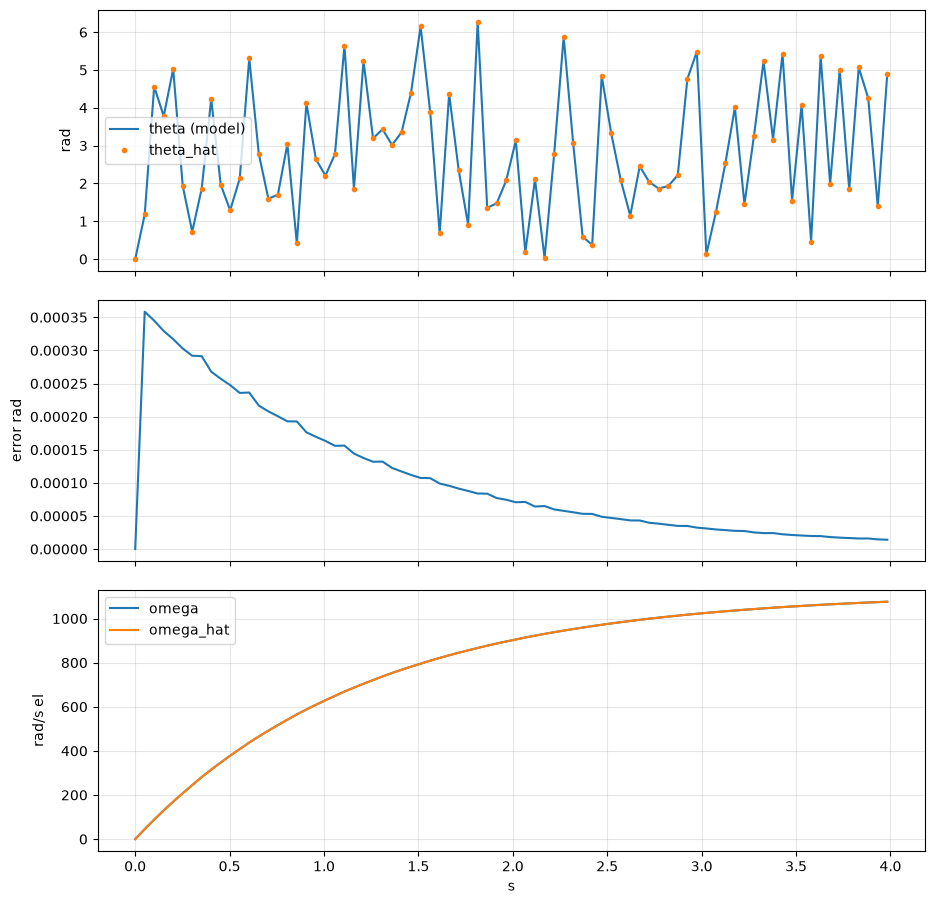

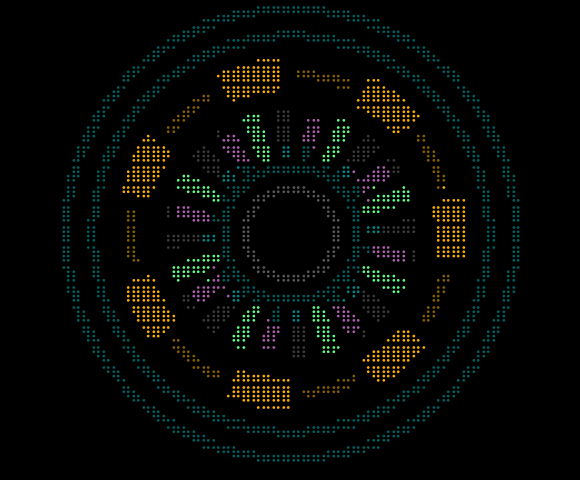

In [19]:
from IPython.display import display
from coaxial.draw import ansi, machine as cross_section

t = [r[0] for r in spin]
fig, (angle, mid, bottom) = figure(rows=3, sharex=True)
angle.plot(t, [r[1] for r in spin], label='theta (model)')
angle.plot(t, [r[2] for r in spin], '.', label='theta_hat')
angle.set_ylabel('rad')
angle.legend()
mid.plot(t, [r[3] for r in spin])
mid.set_ylabel('error rad')
bottom.plot(t, [r[4] for r in spin], label='omega')
bottom.plot(t, [r[5] for r in spin], label='omega_hat')
bottom.set_ylabel('rad/s el')
bottom.set_xlabel('s')
bottom.legend()
show(fig)
pole_pairs = int(drive.params()['motor_pole_pairs'])
theta = spin[-1][1]
amps = tuple(0.05 * math.cos(theta - k * 2.0 * math.pi / 3.0) for k in range(3))
display(ansi.image(cross_section.render(math.degrees(theta) / pole_pairs, slots=24,
                                        poles=2 * pole_pairs, width=58, height=24,
                                        amps=amps, colour=True)))

## 13 The back-EMF chain beside the loop

Op 14 answers a second observer running beside the loop on the same samples: `drive_observer.c`, the pair section 11 ranked first - a dual flux model with a PLL below 800 rad/s electrical, a leaking flux integrator with its lag put back above 3000, blended on the unit vectors between. It drives nothing; it is a second answer to the angle from different arithmetic, so the loop's estimate can be checked without a shaft sensor. The chain reads `v - R i`, and a rotor at rest makes no back-EMF, so `valid` is false below the leak's corner. Four torque currents, each given three seconds to settle because the rotor's j/b is 0.33 s, hold speeds spanning the hand-over, so the table is the blend crossing from one observer to the other. `o['error']` is the chain minus the loop's estimate out of ONE reply, and the rotor's true angle out of another: at 4000 rad/s a 15 ms round trip is 60 radians, so neither column is differenced across the link.

In [20]:
drive.model.reset()
drive.model.configure(j=2e-5, b=6e-5, load=0.0, noise=0.0)
drive.write(id_ref=0.0, iq_ref=0.05, theta=0.0, omega_target=0.0)
drive.on('sensorless')
chain = []
for iq in (0.05, 0.15, 0.35, 0.60):
    drive.write(iq_ref=iq)
    settle = time.monotonic() + 3.0        # the rotor's j/b is 0.33 s
    while time.monotonic() < settle:
        drive.observers.read()
        time.sleep(0.02)
    t0 = time.monotonic()
    while time.monotonic() - t0 < 1.5:
        o = drive.observers.read()
        m = drive.model.read()
        chain.append((m['omega'], o['error'], m['error'], o['blend'],
                      o['lambda_hat'], o['valid']))
        time.sleep(0.02)
last = drive.observers.read()
drive.off()
print({k: last[k] for k in ('valid', 'blend', 'blend_lo', 'blend_hi', 'wc')})
pp = drive.params()['motor_pole_pairs'] or 1
edges = [0.0, 500.0, 1200.0, 2500.0, 1e9]
print('%10s %8s %5s %11s %15s %7s'
      % ('rad/s el', 'rpm', 'n', 'loop deg', 'chain-loop deg', 'blend'))
for lo, hi in zip(edges, edges[1:]):
    band_rows = [r for r in chain if lo <= abs(r[0]) < hi]
    if not band_rows:
        continue
    speed = sum(abs(r[0]) for r in band_rows) / len(band_rows)
    print('%10.0f %8.0f %5d %11.2f %15.2f %7.2f'
          % (speed, speed / pp * 60.0 / math.tau, len(band_rows),
             deg_rms([mc.wrap(r[2]) for r in band_rows]),
             deg_rms([mc.wrap(r[1]) for r in band_rows]),
             sum(r[3] for r in band_rows) / len(band_rows)))
print('lambda   %.5f V.s carried, %.5f in the record'
      % (last['lambda_hat'], drive.params()['motor_lambda_uvs']))

{'valid': True, 'blend': 0.3663613903036293, 'blend_lo': 800.0, 'blend_hi': 3000.0, 'wc': 20.0}
  rad/s el      rpm     n    loop deg  chain-loop deg   blend
       277      377    63        0.00            1.52    0.00
       695      949    64        0.00            5.23    0.00
      1417     1933   126        0.00           27.76    0.27
lambda   0.00561 V.s carried, 0.00500 in the record


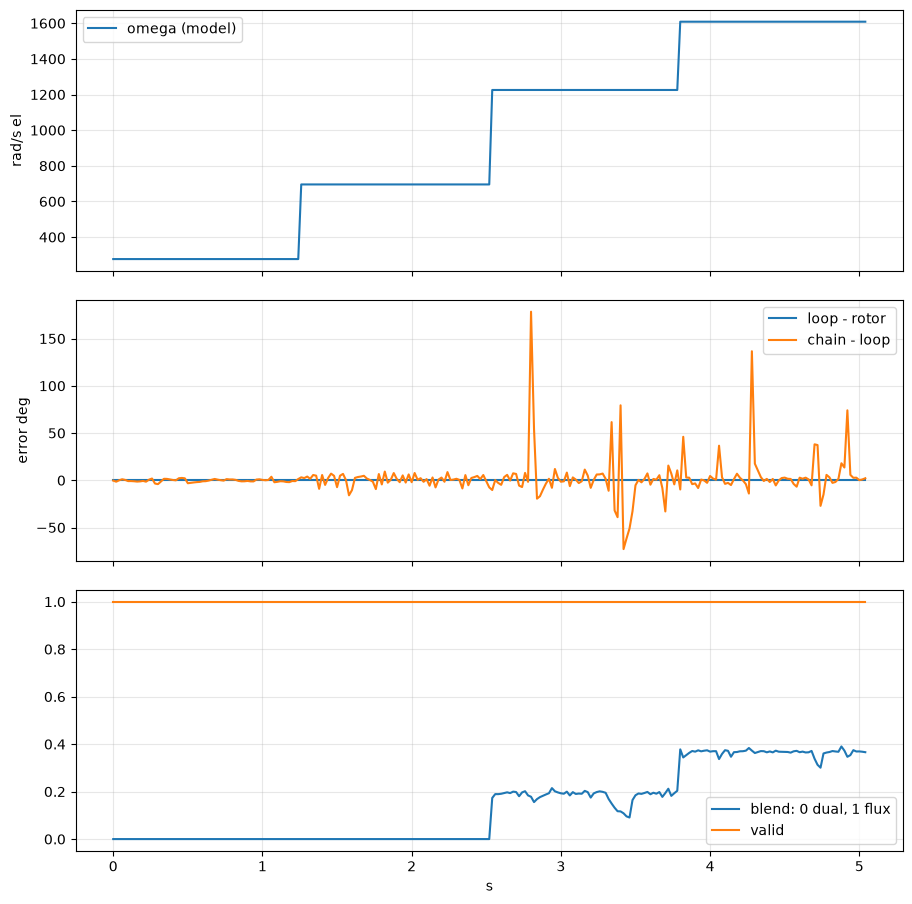

{'source': True}

In [21]:
t = [i * 0.02 for i in range(len(chain))]
fig, (speed, mid, bottom) = figure(rows=3, sharex=True)
speed.plot(t, [r[0] for r in chain], label='omega (model)')
speed.set_ylabel('rad/s el')
speed.legend()
mid.plot(t, [math.degrees(mc.wrap(r[2])) for r in chain], label='loop - rotor')
mid.plot(t, [math.degrees(mc.wrap(r[1])) for r in chain], label='chain - loop')
mid.set_ylabel('error deg')
mid.legend()
bottom.plot(t, [r[3] for r in chain], label='blend: 0 dual, 1 flux')
bottom.plot(t, [1.0 if r[5] else 0.0 for r in chain], label='valid')
bottom.set_xlabel('s')
bottom.legend()
show(fig)
drive.model.reset()
drive.configure(source='adc')

In [22]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 14 Conclusions

In [23]:
bands = {which: band_of(which) for which in ('smo', 'flux', 'blend')}
print('1.  two observers    sliding mode inside %.0f deg from %.0f to %.0f rpm, flux linkage from %.0f to %.0f, '
      'the blend from %.0f to %.0f'
      % (CRITERION_DEG, rpm(bands['smo'][0]), rpm(bands['smo'][1]), rpm(bands['flux'][0]),
         rpm(bands['flux'][1]), rpm(bands['blend'][0]), rpm(bands['blend'][1])))
print('2.  the second L     %.2f deg of bias at 100 A on the plain flux observer, %.1f %% of the torque'
      % (math.degrees(math.atan2((motor.lq - motor.ld) * 100.0, motor.lam)),
         100.0 * (1.0 - math.cos(math.atan2((motor.lq - motor.ld) * 100.0, motor.lam)))))
print('3.  five ranked      ' + ', '.join('%s %.1f to %.1f deg' % (
    n, min(g[n] for _, g in ranked), max(g[n] for _, g in ranked)) for n in RANKED))
gain = max(table, key=lambda row: (min(median(row['smo']), median(row['flux'])) - median(row['blend'])))
print('4.  the blend        gains most at %.0f rad/s: %.1f deg against %.1f for the better single; '
      '%d cycles of headroom a period'
      % (gain['w_e'], median(gain['blend']), min(median(gain['smo']), median(gain['flux'])),
         2 * 2375 - 2921))
print('5.  lambda from |psi| %.3f of the truth at %.0f rad/s with R 30 %% high, %.3f at %.0f'
      % (recovered[SPEEDS[-1]][1], SPEEDS[-1], recovered[SPEEDS[0]][1], SPEEDS[0]))
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = verified[verified.vdc == vdc]
    print('6.  the search       %2.0f V: bw_i %4.0f Hz, f_pll %3.0f Hz, v_inj %.3f, sigma_theta %.2f deg, '
          'trips %d of %d; back-EMF alone loses the rotor at %.0f rpm of %.0f'
          % (vdc, row.bw_i, row.f_pll, row.v_inj, math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub), floor.loc[vdc, 'mean'], no_load_rpm(vdc, motor.lam)))
print('7.  operating point  APC20x10E: %.0f rpm and %.2f N.m at 23 V, %.0f rpm and %.2f N.m at 63 V, the 100 A rating'
      % (operating[23.0][1], operating[23.0][2], operating[63.0][1], operating[63.0][2]))
print('8.  the envelope     %.0f to %.0f rpm at 63 V; peak %.2f to %.2f N.m, continuous %.2f to %.2f N.m = %.0f %% of peak; '
      '%.2f s at 100 A from ambient'
      % (*top, *peak, *cont, 100.0 * cont[0] / peak[0], burst_s(100.0)))
print('9.  low saliency     %.2f A of HF current at 1.5, %.2f at 1.05; at 1 A of headroom 1.02 goes to %s'
      % (methods[1.5][0], methods[1.05][0], methods[1.02][2]))
print('10. the chain, 63 V  holds %.0f to %.0f rpm inside %.1f deg = %.1f %% of the torque; dual alone to %.0f rpm, '
      'plain flux from %.0f'
      % (grip['chain'][0], grip['chain'][1], grip['chain'][2], grip['chain'][3],
         grip['dual'][1], grip['flux'][0]))
errors = [abs(r[3]) for r in spin]
print('11. the model        rotor %.0f to %.0f rad/s electrical; observer error %.4f rad rms, worst %.4f (%.2f deg)'
      % (min(r[4] for r in spin), max(r[4] for r in spin),
         math.sqrt(sum(e * e for e in errors) / len(errors)), max(errors), math.degrees(max(errors))))
print('12. the step         %.1f us period, %d cycles at 475 MHz, exit %d of %d TIM1 ticks; '
      'virtual step sample %d, law %d, advance %d cycles'
      % (state['ts'] * 1e6, state['isr_cycles_max'], state['exit_ticks_max'], 2 * 2375,
         state['cycles']['sample'], state['cycles']['step'], state['cycles']['advance']))
valid = [abs(mc.wrap(r[1])) for r in chain if r[5]]
print('13. the chain on it  %.2f deg rms from the loop where valid, %d of %d; dual below %.0f rad/s, flux above %.0f; '
      'lambda %.5f carried of %.5f'
      % (deg_rms(valid) if valid else math.nan, len(valid), len(chain), last['blend_lo'],
         last['blend_hi'], last['lambda_hat'], drive.params()['motor_lambda_uvs']))

1.  two observers    sliding mode inside 20 deg from 14 to 1364 rpm, flux linkage from 136 to 1364, the blend from 14 to 1364
2.  the second L     18.66 deg of bias at 100 A on the plain flux observer, 5.3 % of the torque
3.  five ranked      dual 0.7 to 3.5 deg, smo 1.0 to 8.9 deg, luen 1.8 to 84.0 deg, eso 4.9 to 61.2 deg, flux 2.4 to 52.6 deg
4.  the blend        gains most at 1000 rad/s: 2.2 deg against 3.0 for the better single; 1829 cycles of headroom a period
5.  lambda from |psi| 0.994 of the truth at 2000 rad/s with R 30 % high, 0.317 at 20
6.  the search       23 V: bw_i 1187 Hz, f_pll  83 Hz, v_inj 0.200, sigma_theta 2.22 deg, trips 0 of 4; back-EMF alone loses the rotor at 31 rpm of 4151
6.  the search       43 V: bw_i  948 Hz, f_pll  50 Hz, v_inj 0.134, sigma_theta 2.72 deg, trips 0 of 4; back-EMF alone loses the rotor at 10 rpm of 7762
6.  the search       63 V: bw_i  948 Hz, f_pll  50 Hz, v_inj 0.134, sigma_theta 4.39 deg, trips 0 of 4; back-EMF alone loses the rotor at 

The angle is covered end to end by three mechanisms rather than one: saliency at rest, a switching term through the middle, an integrator at the top. None covers the range alone, and the hand-overs are where the design work is, which is why the weight should come from what each estimator says about itself rather than a speed threshold someone picked. The blend is not a compromise: in the overlap it beats both, because a lag correction resting on a speed estimate and an integrator's leak are not the same error, and averaging two partly independent errors is worth more than picking the better one. Weighting on the residuals instead was tried and does not work as written - the sliding-mode current residual is dominated by the AFE's own noise, which its low-pass rejects but the residual still shows, so referred to an angle it over-states by orders of magnitude and the weight collapses onto the flux observer at every speed. What the residuals are good for as they stand is validity: whether the sliding-mode observer is on its surface, and whether the flux integrator has drifted off lambda - two conditions a speed threshold cannot see and a supervisor would trip on.

Lambda is recoverable at speed and only at speed: high up the back-EMF dominates `v` and 30 % on R barely moves the magnitude, low down `R i` is most of `v` and the same error swamps it. Run the other way, at low speed with lambda fixed at what the high-speed measurement said, the magnitude error is a function of R alone - the same observer at two speeds separates the two constants the thermal model most wants, R being the winding's temperature and lambda the magnets'. The board's thermal observer has one measurement, the NTC in the drivers' hot spot; a winding resistance and a magnet flux tracked online are two more anchors on the other side of the gap, from an observer the drive is running anyway.

The search's current-loop ceiling is a twentieth of the sampling rate, two periods of pipeline delay wanting the phase margin, and the injection stays eight times above whatever the loop ended up at or the two fight. The observer's bandwidth is no knob: `kalman_gains` iterates the Riccati recursion to its fixed point, so the measured noise sets it and quieter shunts give a faster observer. The floor is the AFE's: the demodulated angle error is `sigma_i` over the demodulator's gain `V_inj Ts (Lq - Ld) / (2 Ld Lq)`, and the 5230SL's saliency of about 1.3 is what the zero-speed method rests on - less, and `decide` picks I/f at its 10 dB threshold. At this AFE's floor the injection clears 10 dB down to a saliency of 1.02; what falls is the exchange rate, 0.39 A of HF current at 1.5 and 2.26 A at 1.05, loss and acoustic noise for no torque, so `i_h_max` is the knob a low-saliency machine is set up around, and where it forces `if_start` the drive ramps open-loop on current until the back-EMF is readable, with a saturation pulse to settle the polarity. The hand-over speed is where the sliding-mode observer's error crosses what the torque can carry; it moves with lambda and the AFE's floor, not with saliency, and on a machine run without injection it is the lowest speed the drive can hold at all.

The envelope is set by the board, not the machine: 100 A instantaneous against the motor's 112.5, the link's no-load speed over lambda, and a continuous rating that is thermal and nothing else. Speed goes as `1/lambda` and torque as `lambda`, so the plus-or-minus 10 % the plants are drawn over puts a 22 % spread on both; everything above the continuous torque is a burst measured in seconds, 1.3 s at 100 A from ambient and less from a warm board, which is what the thermal notebook plans against `seconds_to_limit`. The floor is the injection's, not an observer's: it holds at rest and the back-EMF observers do not. The network was fitted dry, so the phase node's `to_board` is the first number to re-fit with current flowing, `(T_zone - T_board) / P` off a camera into `thermal.set_node`; it sets the continuous rating and every burst time. The board never calls a reading good, it acts: at the record's ceiling it drops MOE, the same path the break uses (invariant 10), and the DC link's 78.15 V full scale on a 63 V rating is the 24 % of headroom that records an over-rating transient instead of clipping it (invariant 11).

The chain is the answer at 63 V: dual flux below 800 rad/s, plain flux above 3000, blended between, so better than 99 % of the commanded torque arrives at every speed the link can reach, and nothing in it needs a sensor this board does not have. Two limits in the board's own terms: neither observer sees a standstill - both live on `v - R i` - which is the injection's job and what the saliency pays for; and the acceleration this stage commands sweeps the whole range in a few hundredths of a second, so the blend has to ride a quantity the observer already holds, its own speed estimate, not a scheduler. What a bench can check without a reference is the current it takes to hold a speed: an angle error costs torque as `cos`, so the phase channels see `1/cos` more current for the same shaft torque, 0.7 % at seven degrees, inside the AFE's noise, and 6 % at twenty, which is not.

On the converters the law reads the injected triple; on the model it reads a PMSM stepped in the same interrupt, with the AFE off, no stage, and a rotor whose true angle is known. `theta_hat` and the model's `theta` ride one reply: two requests are 15 ms apart, six radians at 440 rad/s, so an error across two round trips would be the link's. At -O0 with the caches off a step was 10 040 cycles, 21 us against a 20 us period, and the interrupt outgrew it; with the instruction cache on and -O2 it is 6 756, and the board steps at 2 922 cycles a period with the drivers unpowered (FINDINGS, *The caches were off*). `rho` is the innovation's autocorrelation: a residual that is not white is a model that is wrong, and `ljung_box` judges it. The chain is arithmetic this board already has - no phase-voltage sense, so the voltage it integrates is the commanded duty against the measured DC link, and the current the three phase channels at 3.2 mA a count; its `lambda_hat` is the magnitude the flux model carries, the one quantity here that sees the magnets. On the stand-in the chain is the C's Python mirror stepped over a bounded window of real periods on the stand-in's own rotor, so its error against the loop is the mirror's, not the board's; the C runs on the board, and `test_drive_core.py` holds that C to the Python it was ported from, over plants drawn with the Monte Carlo's own tolerances.

**At the bench.** Flip `SIMULATED` and name the port; the first eleven sections run on the host and need no board, and the last two need the drivers unpowered, since on the model the law's duties reach the gates only if MOE happens to be set. Compare conclusion 12 against the board's own step: `isr_cycles_max` and `exit_ticks_max` are the interrupt measured, and a step past 4 750 ticks is the caches or the optimiser, not the law. Then, with a motor on the stand and `tools/bench/commission.py` run, put the chain to work: `drive.observers.read()['error']` against the loop is the number to watch, and two observers disagreeing is the first thing either being wrong looks like. The current it takes to hold a speed is the check that needs no reference - `1/cos` of the angle error on the phase channels. The stand-in cannot show the search's tune on a real plant, the injection's acoustic cost, or the chain's error against a rotor it does not model; and the continuous rating in conclusion 8 stands on a network fitted dry, so re-fit the phase node's `to_board` with current flowing before planning a burst on it.

## References

* `host/coaxial/model/sensorless.py` - the five observers, `choose_injection` and `decide`
* `host/coaxial/control/loop.py` - the current loop, the machine and the speed loop the search closes
* `host/tools/sim/montecarlo.py` - the firmware's C searched over the link sweep, one process per core
* `host/tests/test_drive_core.py` - the C held to the Python it was ported from, over drawn plants
* `drive/src/drive_observer.c` - the back-EMF chain the board runs beside the loop, op 14
* `host/coaxial/devices/drive.py` - device 10: `state`, `window`, `model`, `observers`, the record
* `host/coaxial/simulated/drive/` - the stand-in this ran on: the PMSM, and the chain stepped over a bounded window
* `docs/FINDINGS.md` - the caches were off: 10 040, 6 756 and 2 922 cycles a step